# Map flood risk area

- Used `monthly-flood-risk-area.csv` data from HII
- It shows the number of flood occurrences for each Tambon/ADM3 in a given calendar month over 17 years (2548-2564).

## Setup

In [10]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

CSV_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/monthly-flood-risk-area.csv')
SHAPE_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/tha_admbnda_adm3_rtsd_20220121_geo.json')
OUTPUT_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean')

## Cleaning

In [11]:
RISK_LABELS = {'เสี่ยงต่ำ': 'low', 'เสี่ยงปานกลาง': 'medium', 'เสี่ยงสูง': 'high'}

flood = pd.read_csv(CSV_PATH)
flood['RISK'] = flood['RISK'].map(RISK_LABELS)
flood['CODE'] = flood['GEOCODE'].astype(str)

print('Rows:', len(flood), '\nTambons:', flood['CODE'].nunique(), '\nMonths:', sorted(flood['Month'].unique()))
flood[['Month', 'CODE', 'TAMBON_E', 'AMPHOE_E', 'COUNT 17 YEAR', 'RISK']].head()

Rows: 27023 
Tambons: 6435 
Months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


,Month,CODE,TAMBON_E,AMPHOE_E,COUNT 17 YEAR,RISK
0,1,120501,Sai Noi,Sai Noi District,1,low
1,1,120503,Nong Phrao Ngai,Sai Noi District,1,low
2,1,120504,Sai Yai,Sai Noi District,1,low
3,1,120505,Khun Si,Sai Noi District,1,low
4,1,120507,Thawi Watthana,Sai Noi District,1,low


## Shape Files

In [12]:
shapes = gpd.read_file(SHAPE_PATH)
shapes['CODE'] = shapes['ADM3_PCODE'].str.removeprefix('TH')

print('ADM3 count:', shapes['CODE'].nunique())
shapes[['ADM3_PCODE', 'ADM3_EN', 'ADM2_EN', 'ADM1_EN']].head()

ADM3 count: 7425


,ADM3_PCODE,ADM3_EN,ADM2_EN,ADM1_EN
0,TH100101,Phraborom Maharatchawang,Phra Nakhon,Bangkok
1,TH100102,Wang Burapha Phirom,Phra Nakhon,Bangkok
2,TH100103,Wat Ratchabophit,Phra Nakhon,Bangkok
3,TH100104,Samran Rat,Phra Nakhon,Bangkok
4,TH100105,San Chaopho Suea,Phra Nakhon,Bangkok


## Join

In [14]:
flood_codes = set(flood['CODE'])
shape_codes = set(shapes['CODE'])

only_in_flood = flood_codes - shape_codes
only_in_shapes = shape_codes - flood_codes

print('Matched geocodes:', len(flood_codes & shape_codes))
print('Only in flood:   ', len(only_in_flood), sorted(only_in_flood))
print('Only in shapes:  ', len(only_in_shapes), '(assume -> norisk)')

Matched geocodes: 6433
Only in flood:    2 ['401050', '630191']
Only in shapes:   992 (assume -> norisk)


## Fix Mismatch

In [15]:
def nearest_shape_code(flood_row):
    amphoe = flood_row['AMPHOE_E'].replace(' District', '').strip()
    same_amphoe = shapes.loc[shapes['ADM2_EN'].str.lower() == amphoe.lower(), 'CODE']
    target_last2 = int(flood_row['CODE'][-2:])
    return min(same_amphoe, key=lambda code: abs(int(code[-2:]) - target_last2))

orphans = flood[flood['CODE'].isin(only_in_flood)].drop_duplicates('CODE')
remap = {row['CODE']: nearest_shape_code(row) for _, row in orphans.iterrows()}

print('Re-mapped orphan flood codes to the nearest shape:')
for old, new in remap.items():
    print(f'  {old} -> {new}')

flood['CODE'] = flood['CODE'].replace(remap)

Re-mapped orphan flood codes to the nearest shape:
  630191 -> 630115
  401050 -> 401017


## Output

In [16]:
SEVERITY = {'norisk': 0, 'low': 1, 'medium': 2, 'high': 3}

for month in range(1, 13):
    risk_by_code = (flood[flood['Month'] == month]
                    .sort_values('RISK', key=lambda s: s.map(SEVERITY))
                    .drop_duplicates('CODE', keep='last')
                    .set_index('CODE')['RISK'])

    month_map = shapes[['ADM3_PCODE', 'ADM3_EN', 'ADM3_TH', 'ADM2_EN', 'ADM1_EN', 'CODE', 'geometry']].copy()
    month_map['RISK'] = month_map['CODE'].map(risk_by_code).fillna('norisk')
    month_map['MONTH'] = month

    output_file = OUTPUT_PATH / f'retro_month{month:02d}_risk.geojson'
    month_map.drop(columns='CODE').to_file(output_file, driver='GeoJSON')

    print(f'{output_file.name}: {len(month_map)} features |', month_map['RISK'].value_counts().to_dict())

retro_month01_risk.geojson: 7425 features | {'norisk': 6661, 'low': 631, 'medium': 133}
retro_month02_risk.geojson: 7425 features | {'norisk': 6805, 'low': 620}
retro_month03_risk.geojson: 7425 features | {'norisk': 7080, 'low': 345}
retro_month04_risk.geojson: 7425 features | {'norisk': 6866, 'low': 559}
retro_month05_risk.geojson: 7425 features | {'norisk': 6266, 'low': 1159}
retro_month06_risk.geojson: 7425 features | {'norisk': 4994, 'low': 2319, 'medium': 112}
retro_month07_risk.geojson: 7425 features | {'norisk': 4573, 'low': 2672, 'medium': 180}
retro_month08_risk.geojson: 7425 features | {'norisk': 4173, 'low': 2287, 'medium': 918, 'high': 47}
retro_month09_risk.geojson: 7425 features | {'norisk': 2891, 'medium': 2133, 'low': 1821, 'high': 580}
retro_month10_risk.geojson: 7425 features | {'norisk': 3115, 'low': 1687, 'medium': 1446, 'high': 1177}
retro_month11_risk.geojson: 7425 features | {'norisk': 3503, 'low': 2161, 'medium': 1454, 'high': 307}
retro_month12_risk.geojson: 74

## Preview

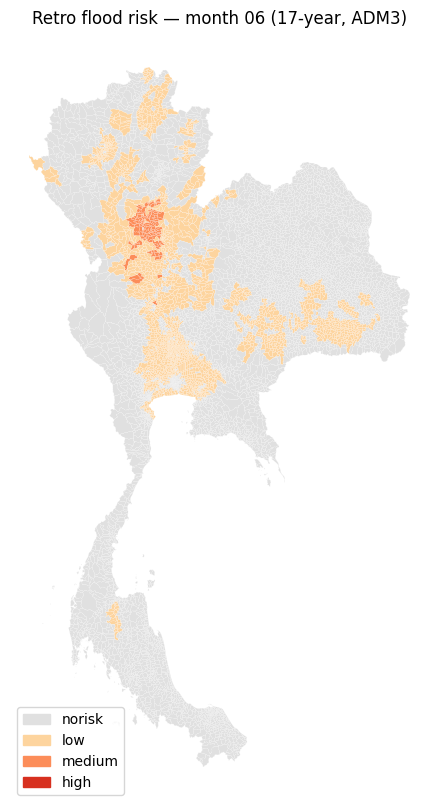

In [17]:
RISK_COLORS = {'norisk': '#E0E0E0', 'low': '#FDD49E', 'medium': '#FC8D59', 'high': '#D7301F'}
preview_month = 6

risk_by_code = (flood[flood['Month'] == preview_month]
                .sort_values('RISK', key=lambda s: s.map(SEVERITY))
                .drop_duplicates('CODE', keep='last')
                .set_index('CODE')['RISK'])

preview = shapes.copy()
preview['RISK'] = preview['CODE'].map(risk_by_code).fillna('norisk')

ax = preview.plot(color=preview['RISK'].map(RISK_COLORS), figsize=(8, 10), edgecolor='white', linewidth=0.1)
ax.set_title(f'Retro flood risk — month {preview_month:02d} (17-year, ADM3)')
ax.axis('off')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=RISK_COLORS[r], label=r) for r in ['norisk', 'low', 'medium', 'high']], loc='lower left')